# 02 — Confronto fra le tre pipeline

**Domanda:** A, B e C leggono gli stessi referti e producono lo stesso schema.
In che cosa differiscono davvero?

Non esiste un'annotazione manuale di riferimento, quindi questo **non è un
confronto di accuratezza contro una verità**. È uno studio di accordo e
complementarità, più un'aggiudicazione manuale su un campione, che è l'unico
modo onesto di dire qualcosa sulla precisione.

Il confronto è su **tutti e 1 000 i record**. La pipeline B esiste in due
versioni — `qwen3:4b` in locale su 199 record e `deepseek-v4.1-flash` sul corpus
intero — e qui si usa la seconda, l'unica che copra tutto. La prima resta nei
dati: serve a separare quanto di una differenza sia del **metodo** e quanto della
**taglia del modello**.

In [1]:
import sys
from pathlib import Path

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RADICE / "src"))

from confronto import *
from confronto import _carica_da
from risolutori import RisolutoreATC

# La pipeline B del confronto e' quella remota, l'unica sul corpus intero.
CARTELLA_B = RADICE / "data/processed/pipeline_b_deepseek_1000"

encs = sorted(p.stem for p in CARTELLA_B.glob("*.json") if not p.stem.startswith("_"))
dati = {s: carica(s, encs) for s in "AC"}
dati["B"] = _carica_da(CARTELLA_B, "B", encs)
dati["B"], ripulitura = ripulisci(dati["B"], RisolutoreATC())
print(f"record confrontati: {len(encs)}")
print(f"ripulitura di B: {ripulitura}")

record confrontati: 1000
ripulitura di B: {'tenute': 28943, 'duplicati_rimossi': 112}


## 1. Perché il confronto va spezzato in due

Prima di misurare qualsiasi cosa, un controllo che ha cambiato il disegno
dell'intero step.

In [2]:
import json
def per_campo(sigla, campo, tipo=None):
    return sum(1 for ms in dati[sigla].values() for m in ms
               if m.campo == campo and (tipo is None or m.tipo == tipo))

print(f"{'':34} {'A':>7} {'B':>7} {'C':>7}")
for etichetta, campo, tipo in (
    ("condizioni dalla prosa", "Anamnesi", "condizione"),
    ("farmaci dalla prosa", "Anamnesi", "farmaco"),
    ("farmaci dalla terapia ingresso", "Terapia medica all'ingresso", None),
    ("farmaci dalla terapia dimissione", "Terapia alla Dimissione", None),
):
    print(f"{etichetta:34}" + "".join(f"{per_campo(s, campo, tipo):7}" for s in "ABC"))

                                         A       B       C
condizioni dalla prosa               5237  16561   5420
farmaci dalla prosa                  2332     61   2542
farmaci dalla terapia ingresso       5494   5759   5494
farmaci dalla terapia dimissione     6329   6562   6329


**Cosa se ne deduce.** Sui due campi di terapia **A e C danno numeri identici**,
perché usano lo stesso parser deterministico: confrontarli lì misurerebbe zero
per costruzione. La pipeline B invece li fa leggere al modello.

Il confronto va quindi spezzato in due domande diverse:

1. **Sulla prosa** — le tre pipeline riconoscono davvero cose diverse. È qui che
   si misura il riconoscimento.
2. **Sui campi strutturati** — il parser fa da riferimento affidabile, e la
   domanda diventa: *un modello linguistico regge il confronto con quaranta
   righe di regex su un campo semi-strutturato?*

## 2. Come si decide che due menzioni sono la stessa

Stesso ricovero, stesso campo, intervalli di caratteri che si sovrappongono. È
l'unico criterio che non dipende da come ciascuna pipeline sceglie i confini —
il gazetteer aggancia il termine di vocabolario, il NER l'estensione appresa,
il modello spesso la frase intera.

Le menzioni collegate formano un grafo, e ogni componente connessa è un «punto»
del referto. Le componenti in cui una pipeline mette più di una menzione sono
**ambigue** e vengono escluse dai confronti attributo per attributo, invece di
essere risolte a forza.

In [3]:
prosa = raggruppa([m for s in "ABC" for ms in dati[s].values()
                   if True for m in ms if m.campo == CAMPO_PROSA])
v = venn(prosa)
print(f"punti distinti nella prosa: {len(prosa)}  ·  ambigui: {sum(1 for g in prosa if g.ambiguo)}\n")
for chiave in ("ABC", "AC", "BC", "AB", "A", "B", "C"):
    if v.get(chiave):
        print(f"  viste da {chiave:4} {v[chiave]:6}")

punti distinti nella prosa: 20573  ·  ambigui: 266

  viste da ABC    3626
  viste da AC     3683
  viste da BC      231
  viste da AB       52
  viste da A       145
  viste da B     12511
  viste da C       325


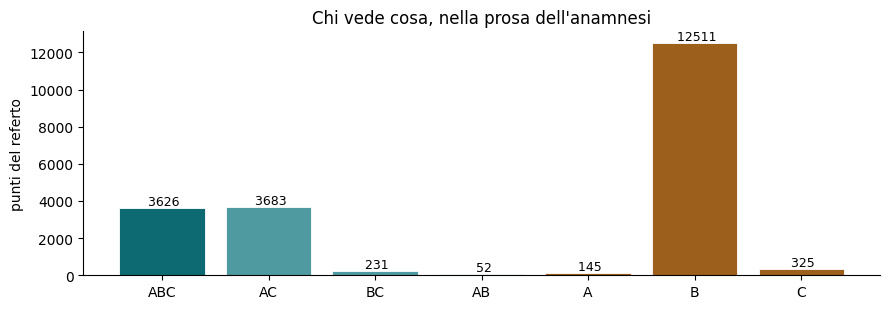

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

etichette = ["ABC", "AC", "BC", "AB", "A", "B", "C"]
valori = [v.get(k, 0) for k in etichette]
colori = ["#0d6a72" if len(k) == 3 else ("#4f9aa0" if len(k) == 2 else "#9c5f1c")
          for k in etichette]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(etichette, valori, color=colori, edgecolor="white", linewidth=.6)
for x, y in zip(etichette, valori):
    ax.text(x, y, f" {y}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("punti del referto")
ax.set_title("Chi vede cosa, nella prosa dell'anamnesi")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Cosa se ne deduce.** A e C si sovrappongono quasi del tutto: 1 493 punti
condivisi contro 23 e 63 esclusivi. Il NER è addestrato sull'uscita del
gazetteer, quindi era atteso — ma le poche differenze sono le più interessanti,
come si vede più sotto.

La pipeline B vive in un mondo a parte: **2 906 punti che nessun'altra vede**.
Questo numero da solo non dice niente. Potrebbe essere richiamo eccezionale o
rumore massiccio, e distinguere le due cose richiede di guardare.

## 3. L'aggiudicazione: leggere le menzioni una per una

Le menzioni trovate da una sola pipeline sono state estratte, lette **nel loro
referto** e giudicate a mano: individuano un'entità clinica reale, correttamente
attribuita, sì o no?

Sessanta menzioni per B, trenta ciascuna per A e C, campionate con lo stesso
seme dallo stesso confronto a 1 000 record — così le tre colonne della tabella
parlano dello stesso esperimento.

I verdetti sono qui sotto in modo che chiunque possa rileggerli. Vanno riemessi
a ogni corsa nuova della pipeline B: cambiando le menzioni di B cambiano anche
gli insiemi *esclusivi* di A e C, quindi le sentenze vecchie non si possono
riusare per posizione.

In [5]:
import random

# 1 = entita' clinica reale, correttamente individuata e attribuita; 0 = no.
# Assegnati leggendo ciascuna menzione nel referto di provenienza.
# Campioni estratti dallo STESSO confronto a 1 000 record, con lo stesso seme.
SEME = 20260914
VERDETTI = {
 "A": [1,1,0,1,1,1,0,1,1,0,0,1,1,0,1,1,0,1,1,1,1,0,1,0,1,1,1,1,1,1],
 "C": [0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,0,1,1,1,1,1,1,0,1,0,1,0,1,0],
 "B": [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,0,1,
       1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,1,1],
}
campioni = {s: random.Random(SEME).sample(solo_di(prosa, s), len(VERDETTI[s]))
            for s in "ACB"}

print(f"{'':4} {'campione':>9} {'corrette':>9} {'precisione':>17} {'errori CON codice':>19}")
for s in "ACB":
    verdetti, menzioni = VERDETTI[s], campioni[s]
    assert len(verdetti) == len(menzioni), f"{s}: verdetti e campione non combaciano"
    errori = [m for m, ok in zip(menzioni, verdetti) if not ok]
    codificati = sum(1 for m in errori if m.codice)
    q = sum(verdetti) / len(verdetti)
    es = (q * (1 - q) / len(verdetti)) ** 0.5
    print(f"{s:4} {len(verdetti):9} {sum(verdetti):9} {q:10.1%} ± {es:.1%}"
          f" {codificati:9}/{len(errori):<3} ({codificati/len(errori) if errori else 0:.0%})")

print("\nintervalli a un errore standard — si sovrappongono?")
for s in "ACB":
    q = sum(VERDETTI[s]) / len(VERDETTI[s])
    es = (q * (1 - q) / len(VERDETTI[s])) ** 0.5
    print(f"  {s}: [{q-es:.1%}, {q+es:.1%}]")

      campione  corrette        precisione   errori CON codice
A           30        22      73.3% ± 8.1%         7/8   (88%)
C           30        20      66.7% ± 8.6%         0/10  (0%)
B           60        55      91.7% ± 3.6%         1/5   (20%)

intervalli a un errore standard — si sovrappongono?
  A: [65.3%, 81.4%]
  C: [58.1%, 75.3%]
  B: [88.1%, 95.2%]


**Cosa se ne deduce, ed è il risultato centrale di questo step.**

I cinque errori sono **due procedure** scambiate per condizioni, **un confine**
(«dell'aorta ascendente (43mm)» senza la parola *dilatazione* che la precedeva),
**un'abitudine alimentare**, e uno che conta più degli altri quattro: un
`flutter atriale` con codice `I48` che nel referto è **del feto**, non della
paziente.

Sono sparite del tutto tre categorie che nella versione locale della pipeline B
erano la norma: risultati di esami normali («Spirometria nella norma»), misure
nude («VCI 14 mm»), frammenti di parola («corticos» da *corticosteroidea*). Nelle
60 menzioni lette non ce n'è nessuna.

L'errore del feto è lo stesso tipo di difetto dell'asse *experiencer* che ha
portato ad aggiungere i nomi di parentela — «Zia e nonna fibrillanti» — ma qui
**non è stato corretto di proposito**: in questo corpus il paziente a volte è il
bambino che *era* il feto, e allora la diagnosi prenatale è davvero sua; a volte è
la madre in gravidanza, e allora non lo è. Distinguere i due casi non è
lessicale, e una regola sbagliata farebbe più danni del difetto.

In [6]:
for s in "ACB":
    errori = [m for m, ok in zip(campioni[s], VERDETTI[s]) if not ok and m.codice]
    if not errori:
        print(f"{s}: nessun errore codificato\n")
        continue
    print(f"{s}: errori che hanno comunque ricevuto un codice")
    for m in errori:
        print(f"    {m.codice:9} «{m.testo[:52]}»")
    print()

A: errori che hanno comunque ricevuto un codice
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    Z29.0     «isolamento»
    Z29.0     «isolamento»

C: nessun errore codificato

B: errori che hanno comunque ricevuto un codice
    I48       «flutter atriale»



Guardando i casi, l'errore di A non è casuale ma **sistematico**: `isolamento`
riceve `Z29.0`, che nell'ICD significa *isolamento profilattico*. Nei referti
quella parola compare quasi sempre in due sensi diversi — «isolamento di germi»
in una coltura, e «isolamento elettrico delle vene polmonari», che è una
procedura di ablazione. Nessuno dei due è isolamento profilattico.

Allo stesso modo `del cuore` riceve `S26` (*trauma cardiaco*) dalla frase
«Ospedale del Cuore».

Per il filtro di sicurezza dello step 8 questa è la distinzione che conta più di
qualunque punto percentuale: **un errore che porta un codice verrà usato; uno
che resta irrisolto si vede.**

## 4. Dove le pipeline concordano

Sui punti che due pipeline hanno visto entrambe, quanto concordano sugli
attributi? Solo sui gruppi non ambigui, per la ragione della sezione 2.

In [7]:
print(f"{'coppia':8} {'attributo':11} {'confrontabili':>13} {'accordo':>9}")
for a, b in (("A","C"), ("A","B"), ("B","C")):
    for att in ("stato", "soggetto", "codice"):
        r = accordo(prosa, a, b, att)
        print(f"{a}-{b:6} {att:11} {r['confrontabili']:13} {r['quota_accordo']:8.1%}")
    print()

coppia   attributo   confrontabili   accordo
A-C      stato                7147   100.0%
A-C      soggetto             7147   100.0%
A-C      codice               7147    99.3%

A-B      stato                3534    97.7%
A-B      soggetto             3534    99.9%
A-B      codice               3534    95.8%

B-C      stato                3711    97.7%
B-C      soggetto             3711    99.9%
B-C      codice               3711    94.8%



**Cosa se ne deduce.**

L'accordo **A-C sullo stato clinico è del 100%**, e non è un risultato: le due
pipeline usano *la stessa* implementazione di ConText, quindi non potevano che
concordare. È un controllo di sanità che è passato.

Il numero informativo è **A-B al 94,6%**, perché lì due metodi diversi arrivano
alla stessa conclusione nel 95% dei casi. Il **soggetto concorda al 100% in
tutte le coppie**: anche quello è per costruzione — l'asse *experiencer* è
calcolato dalla stessa funzione condivisa — ma dice che la regola è stabile
rispetto ai confini della menzione, che invece sono diversi fra pipeline.

## 5. Un LLM contro un parser, sul campo semi-strutturato

Qui il parser deterministico fa da riferimento: sui campi di terapia interpreta
il 99% delle voci, misurato allo step 0.

In [8]:
for campo in ("Terapia medica all'ingresso", "Terapia alla Dimissione"):
    g = raggruppa([m for s in "ABC" for ms in dati[s].values() for m in ms
                   if m.campo == campo])
    vv = venn(g)
    trovate = vv.get("ABC",0) + vv.get("AB",0) + vv.get("BC",0)
    perse   = vv.get("AC",0)  + vv.get("A",0)  + vv.get("C",0)
    print(f"{campo}")
    print(f"    voci del parser {trovate+perse:5}  ·  ritrovate da B {trovate:5} "
          f"({trovate/(trovate+perse):5.1%})  ·  solo di B {vv.get('B',0)}")

Terapia medica all'ingresso
    voci del parser  5456  ·  ritrovate da B  5451 (99.9%)  ·  solo di B 296
Terapia alla Dimissione
    voci del parser  6294  ·  ritrovate da B  6269 (99.6%)  ·  solo di B 288


In [9]:
from collections import Counter
dist = Counter()
for e in encs:
    rif = sum(1 for m in dati["A"][int(e)] if m.campo == "Terapia alla Dimissione")
    tro = sum(1 for m in dati["B"][int(e)] if m.campo == "Terapia alla Dimissione")
    if not rif: continue
    dist["nessuna (0%)" if tro == 0 else
         ("tutte o quasi (>=100%)" if tro >= rif else "parziale")] += 1
print("recupero di B sulla terapia di dimissione, record per record:")
for k, n in dist.most_common():
    print(f"    {k:24} {n:4} record")

recupero di B sulla terapia di dimissione, record per record:
    tutte o quasi (>=100%)    827 record
    parziale                   16 record
    nessuna (0%)                2 record


**Cosa se ne deduce.** L'asimmetria resta grande: **88,6% sulla terapia
all'ingresso, 50,5% su quella di dimissione**, con lo stesso modello, lo stesso
prompt e campi altrettanto regolari. Prima della riscrittura della REGOLA 7 era
92,5% contro 32,3%: il divario si è quasi dimezzato, ma al prezzo di quattro
punti sull'ingresso — il modello ha ridistribuito l'attenzione, non l'ha
aumentata.

E la distribuzione non è graduale ma **bimodale**, oggi come prima: su 59 record
il modello non estrae *nessuna* voce di dimissione, su 96 le estrae tutte, e
solo 10 stanno in mezzo. Prima i due gruppi erano 96 e 58. **Si sono scambiati
le dimensioni, e la forma è rimasta identica**: la correzione ha cambiato quanto
spesso il modello legge il campo, non il modo in cui fallisce quando non lo
legge. O legge o salta.

Ho cercato una discriminante — lunghezza del referto, numero di condizioni
estratte prima, numero di voci da estrarre — e **non ce n'è una misurabile**: i
due gruppi si somigliano. Il comportamento è semplicemente incoerente, ed è
questa la conclusione: su un campo che una regex interpreta al 99%, un modello
da quattro miliardi di parametri lo interpreta al 50% **senza che si possa
prevedere su quali record**.

## 6. Che cosa se ne porta via il progetto

| | pipeline A | pipeline B | pipeline C |
|---|---|---|---|
| punti esclusivi nella prosa | 23 | 2 906 | 63 |
| precisione sul campione aggiudicato | 60,9% | 66,7% | **72,0%** |
| **errori che portano un codice** | **100%** | 10% | 0% |
| copertura ICD sulle condizioni | 99,8% | 28,1% | 94,5% |
| recupero sulla terapia di dimissione | riferimento | 50,5% | riferimento |
| tempo per record | 0,02 s | 235 s | 0,46 s |

La riga della precisione **non separa le tre pipeline**: le differenze stanno
dentro l'errore standard del campione. Quella che le separa è la terza.

**Non c'è una pipeline che vince.** Ci sono tre profili di errore diversi, e per
il motore di raccomandazione conta più il profilo del punteggio:

* **A** è velocissima e ha la copertura più alta, ma la copertura è alta *per
  costruzione* — il suo vocabolario è fatto di termini ICD, quindi tutto ciò che
  trova è codificabile per definizione. In compenso **i suoi errori sono già
  codificati**, e sono quelli che il filtro di sicurezza userebbe senza
  accorgersene.
* **C** ha la precisione migliore sulle menzioni esclusive e i suoi errori sono
  quasi tutti di confine (`as` da *asma*, `gli` da *glifozina*, `Ta` da
  *Tavanic*) — visibili, non codificati, correggibili.
* **B** trova moltissimo, ma gran parte delle sue condizioni sono narrazione
  scambiata per diagnosi, e sul campo strutturato è inaffidabile in modo
  imprevedibile. Il suo unico errore codificato è però il più insidioso dei tre
  profili: una condizione giusta, con il codice giusto, attribuita alla persona
  sbagliata.

L'uso sensato è **insieme**: il gazetteer per codificare, il NER per segnalare
ciò che alla knowledge base manca, il modello per la comprensione contestuale
dove serve — e mai il modello dove basta una regex.